In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [9]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

#Parameters
symbol = "^NDX"
starting_balance = 25000
risk_percent = 0.005      
risk_reward = 1

retracement_type = "range"

strategy_timezone = "Europe/London"
number_of_volume_bins = 20
high_volume_percentile = 70
stop_buffer = 1

# Use 1 for an index/CFD model, 2 for MNQ or 20 for NQ
point_value = 1

# Allows calculations for decimals
allow_fractional_size = True

In [10]:
# 30 days, 5-minute
nasdaq = yf.download(symbol,period="30d",interval="5m",auto_adjust=False,progress=False)

# Simplifies headings and prevents errors
if isinstance(nasdaq.columns, pd.MultiIndex):
    nasdaq.columns = nasdaq.columns.get_level_values(0)

nasdaq = nasdaq[["Open", "High", "Low", "Close", "Volume"]].dropna()

# Convert the timesfrom 14:30 to 2:30 pm (London)
if nasdaq.index.tz is None:
    nasdaq.index = nasdaq.index.tz_localize("UTC")
# Puts the candles into the correct timezone. 
# Extracts the date so you can group candles by trading day.
nasdaq.index = nasdaq.index.tz_convert(strategy_timezone)
nasdaq["Date"] = nasdaq.index.date
# Each row represents one five-minute candle
print("Rows downloaded:", len(nasdaq))
display(nasdaq.head().round(2))

Rows downloaded: 2340


Price,Open,High,Low,Close,Volume,Date
Datetime,,,,,,
2026-08-06 14:30:00+01:00,29235.29,29248.02,29128.05,29224.44,0,2026-08-06
2026-08-06 14:35:00+01:00,29230.69,29329.16,29218.12,29277.36,39498424,2026-08-06
2026-08-06 14:40:00+01:00,29267.31,29354.50,29267.31,29342.37,25687580,2026-08-06
2026-08-06 14:45:00+01:00,29343.99,29421.29,29343.33,29421.29,25924397,2026-08-06
2026-08-06 14:50:00+01:00,29416.19,29433.69,29382.26,29382.26,23386908,2026-08-06


In [11]:
# The price data you give the function, such as candles between 2:30 and 3:00 pm.
# Divides the full price range into 20 smaller price sections
def find_high_volume_areas(data, bins=20):
    lowest_price = data["Low"].min()
    highest_price = data["High"].max()

    if highest_price <= lowest_price:
        return []

# Creates the boundaries of the price sections. 
# Stores the estimated volume inside each section.
    price_edges = np.linspace(lowest_price, highest_price, bins + 1)
    volume_in_each_bin = np.zeros(bins)

# Goes through the DataFrame one row at a time. 
# In your dataset, each row represents one five-minute candle.
    for index, candle in data.iterrows():
        bins_touched = []
# i+1 shows its starting price and ending price.
        for i in range(bins):
            bin_low = price_edges[i]
            bin_high = price_edges[i + 1]
# This checks whether the candle’s price range overlaps the current bin
            if candle["High"] >= bin_low and candle["Low"] <= bin_high:
                bins_touched.append(i)
# If the candle touched at least one price bin, continue.
# Then the candle’s volume is divided equally across all the bins it touched
        if len(bins_touched) > 0:
            shared_volume = candle["Volume"] / len(bins_touched)

            for i in bins_touched:
                volume_in_each_bin[i] += shared_volume

    volumes_above_zero = volume_in_each_bin[volume_in_each_bin > 0]
# A safety check:
    if len(volumes_above_zero) == 0:
        return []

    volume_cutoff = np.percentile(volumes_above_zero,high_volume_percentile)

    high_volume_areas = []

    for i in range(bins):
        if volume_in_each_bin[i] >= volume_cutoff:
            high_volume_areas.append((price_edges[i], price_edges[i + 1]))

    return high_volume_areas


In [12]:
trades = []
account_balance = starting_balance

# Go through data one day at a time
for date, day in nasdaq.groupby("Date"):

    start_time = pd.Timestamp("14:30").time()
    end_time = pd.Timestamp("15:00").time()
    trade_end_time = pd.Timestamp("16:30").time()

    first_half_hour = day[(day.index.time >= start_time) & (day.index.time < end_time)]

    if first_half_hour.empty:
        continue

# Price range the retracement
    if retracement_type == "candle":
        retracement_data = first_half_hour.iloc[:1]
    else:
        retracement_data = first_half_hour

    range_high = retracement_data["High"].max()
    range_low = retracement_data["Low"].min()

    volume_areas = find_high_volume_areas(first_half_hour,number_of_volume_bins)

    # Only keep volume areas that overlap my chosen retracement range
    valid_areas = []

    for area_low, area_high in volume_areas:
        overlap_low = max(area_low, range_low)
        overlap_high = min(area_high, range_high)

        if overlap_low <= overlap_high:
            valid_areas.append((overlap_low, overlap_high))

    if len(valid_areas) == 0:
        continue

    later_data = day[(day.index.time >= end_time) & (day.index.time <= trade_end_time)]

    price_position = "inside"

    for i in range(len(later_data)):
        candle = later_data.iloc[i]
        candle_time = later_data.index[i]

        # First wait for a close outside the range
        if price_position == "inside":
            if candle["Close"] > range_high:
                price_position = "above"
            elif candle["Close"] < range_low:
                price_position = "below"

            continue

        if price_position == "above":
            direction = "Long"
        else:
            direction = "Short"

        entry = None
        chosen_area = None

        # Check whether this candle retraced into a high-volume area
        for area_low, area_high in valid_areas:
            candle_touched_area = (candle["High"] >= area_low and candle["Low"] <= area_high)

            if candle_touched_area:
                if direction == "Long":
                    entry = area_high
                else:
                    entry = area_low

                chosen_area = (area_low, area_high)
                break

        if entry is None:
            continue

        # Stop goes on the other side of the original range
        if direction == "Long":
            stop = range_low - stop_buffer
            risk_in_points = entry - stop
            target = entry + (risk_in_points * risk_reward)
        else:
            stop = range_high + stop_buffer
            risk_in_points = stop - entry
            target = entry - (risk_in_points * risk_reward)

        if risk_in_points <= 0:
            continue

        # Risk 0.5% of the latest account balance
        money_at_risk = account_balance * risk_percent
        money_risked_by_one_unit = risk_in_points * point_value
        position_size = money_at_risk / money_risked_by_one_unit

        if allow_fractional_size is False:
            position_size = np.floor(position_size)

        if position_size <= 0:
            continue

        result = "Open"
        profit = 0
        exit_price = np.nan
        exit_time = pd.NaT

        # Start from the following candle because the entry candle's order is unknown
        future_candles = later_data.iloc[i + 1:]

        for future_time, future in future_candles.iterrows():

            if direction == "Long":
                stop_was_hit = future["Low"] <= stop
                target_was_hit = future["High"] >= target
            else:
                stop_was_hit = future["High"] >= stop
                target_was_hit = future["Low"] <= target

            # If both are reached in one candle, count the stop first
            if stop_was_hit:
                result = "Loss"
                exit_price = stop
                exit_time = future_time
                profit = -money_at_risk
                account_balance += profit
                break

            elif target_was_hit:
                result = "Win"
                exit_price = target
                exit_time = future_time
                profit = money_at_risk * risk_reward
                account_balance += profit
                break

        trades.append({"Date": date,"Direction": direction,"Range Low": range_low,"Range High": range_high,"Volume Area Low": chosen_area[0],"Volume Area High": chosen_area[1],"Entry Time": candle_time,"Entry": entry,"Stop": stop,"Target": target,"Money Risked": money_at_risk,"Position Size": position_size,"Exit Time": exit_time,"Exit": exit_price,"Result": result,"Profit": profit,"Account Balance": account_balance})

        # Only take one trade per day
        break

trades_df = pd.DataFrame(trades)
display(trades_df.head(20).round (2))


,Date,Direction,Range Low,Range High,Volume Area Low,Volume Area High,Entry Time,Entry,Stop,Target,Money Risked,Position Size,Exit Time,Exit,Result,Profit,Account Balance
0,2026-08-06,Long,29128.05,29433.69,29418.41,29433.69,2026-08-06 15:45:00+01:00,29433.69,29127.05,29740.33,125.00,0.41,NaT,NaN,Open,0.00,25000.00
1,2026-08-07,Short,29538.19,29701.51,29628.01,29636.18,2026-08-07 15:25:00+01:00,29628.01,29702.51,29553.52,125.00,1.68,2026-08-07 15:40:00+01:00,29553.52,Win,125.00,25125.00
2,2026-08-10,Long,29612.54,29724.05,29685.02,29690.59,2026-08-10 15:50:00+01:00,29690.59,29611.54,29769.65,125.62,1.59,NaT,NaN,Open,0.00,25125.00
3,2026-08-12,Short,29750.59,29876.73,29769.51,29775.82,2026-08-12 16:05:00+01:00,29769.51,29877.73,29661.29,125.62,1.16,NaT,NaN,Open,0.00,25125.00
4,2026-08-13,Long,29757.62,30073.43,30026.06,30041.85,2026-08-13 16:30:00+01:00,30041.85,29756.62,30327.09,125.62,0.44,NaT,NaN,Open,0.00,25125.00
5,2026-08-18,Short,29514.43,29676.77,29546.90,29555.02,2026-08-18 15:20:00+01:00,29546.90,29677.77,29416.03,125.62,0.96,NaT,NaN,Open,0.00,25125.00
6,2026-08-19,Short,29317.44,29647.63,29366.97,29383.48,2026-08-19 15:15:00+01:00,29366.97,29648.63,29085.31,125.62,0.45,NaT,NaN,Open,0.00,25125.00
7,2026-08-21,Short,29181.73,29365.00,29227.55,29236.71,2026-08-21 15:45:00+01:00,29227.55,29366.00,29089.10,125.62,0.91,NaT,NaN,Open,0.00,25125.00
8,2026-08-26,Short,29135.58,29261.94,29205.07,29211.39,2026-08-26 16:00:00+01:00,29205.07,29262.94,29147.21,125.62,2.17,NaT,NaN,Open,0.00,25125.00
9,2026-08-27,Long,29366.42,29535.04,29476.02,29484.45,2026-08-27 15:40:00+01:00,29484.45,29365.42,29603.48,125.62,1.06,NaT,NaN,Open,0.00,25125.00


In [13]:
# Shows how well my trades performed
if trades_df.empty:
    print("No trades were found.")
else:
    closed_trades = trades_df[trades_df["Result"].isin(["Win", "Loss"])]
    wins = (closed_trades["Result"] == "Win").sum()
    losses = (closed_trades["Result"] == "Loss").sum()
    total_closed = wins + losses

    if total_closed > 0:
        win_rate = (wins / total_closed) * 100
    else:
        win_rate = 0
    print("Closed trades:", total_closed)
    print("Wins:", wins)
    print("Losses:", losses)
    print("Win rate:", round(win_rate, 2), "%")
    print("Total profit:", round(closed_trades["Profit"].sum(), 2))
    print("Final account balance:", round(account_balance, 2))


Closed trades: 4
Wins: 2
Losses: 2
Win rate: 50.0 %
Total profit: -1.25
Final account balance: 24998.75


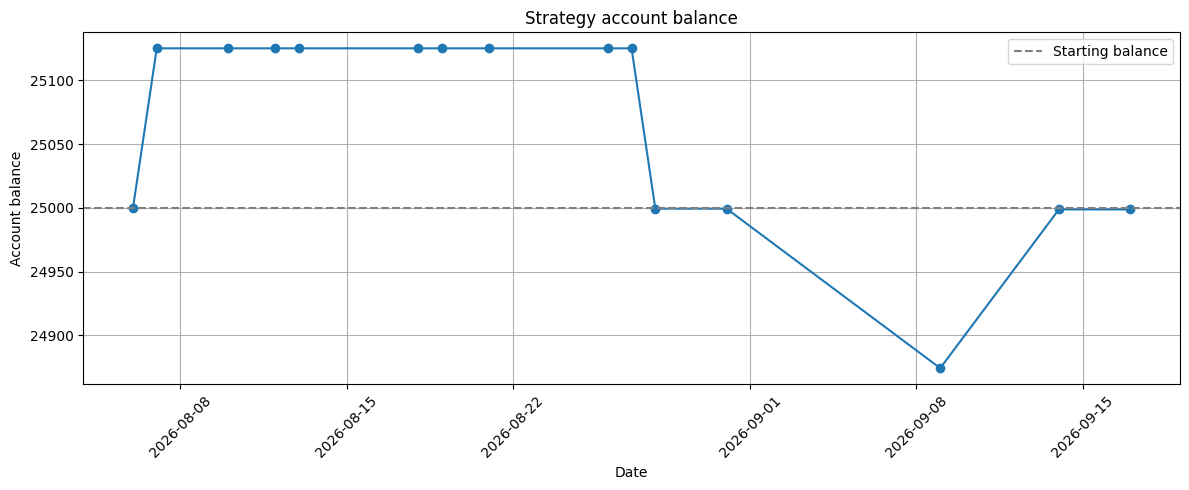

In [14]:
# Shows account balance after each trade
if not trades_df.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(trades_df["Date"],trades_df["Account Balance"],marker="o")
    
    plt.axhline(starting_balance,color="grey",linestyle="--",label="Starting balance")
    plt.title("Strategy account balance")
    plt.xlabel("Date")
    plt.ylabel("Account balance")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
